# Stacked cluster masses — results & profiles

Visualise the output of the **`CLClusterMass`** stage:

- stacked halo mass per cluster bin (the headline plot),
- the mass–richness relation in redshift slices,
- goodness-of-fit and clusters-per-bin diagnostics,
- stacked profiles with the best-fit NFW model overlaid (needs the
  `CLClusterEnsembleProfiles` pickle too),
- individual-cluster masses, if `fit_individual` was on.

Edit the two paths in the first cell if your files live elsewhere. Every
section degrades gracefully: if an input is missing it prints a note and
skips, rather than erroring.

In [1]:
%matplotlib inline
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

# --- paths (edit if needed) -------------------------------------------------
MASSES_PKL   = Path("outputs/cluster_masses.pkl")      # output of CLClusterMass
PROFILES_PKL = Path("/sps/lsst/groups/clusters/cl_pipeline_project/TXPipe_data/cosmodc2/outputs-full-2026/cluster_profiles.pkl")    # output of CLClusterEnsembleProfiles
#   ^ only needed for the profile+model overlays. If it lives in another
#     stage's output dir, point this at it.

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

## Load the fit results

In [2]:
with open(MASSES_PKL, "rb") as f:
    masses = pickle.load(f)

print(f"{len(masses)} cluster bins in {MASSES_PKL.name}\n")

records = []
for bin_key, entry in masses.items():
    ens = entry.get("ensemble")
    rec = {
        "bin_key": str(bin_key),
        "n_cl": entry.get("n_cl"),
        "z_eff": entry.get("z_eff"),
        "profile_type": entry.get("profile_type"),
        "is_deltasigma": entry.get("is_deltasigma"),
        "edges": entry.get("cluster_bin_edges") or {},
        "fitted": ens is not None,
    }
    if ens:
        rec.update(
            m=ens["m"], m_err=ens["m_err"],
            logm=ens["logm"], logm_err=ens["logm_err"],
            reduced_chi2=ens.get("reduced_chi2"),
            concentration=ens.get("concentration"),
            cov_key=ens.get("cov_key"),
        )
    records.append(rec)

# quick peek
for r in records:
    tag = "" if r["fitted"] else "  (NOT fitted)"
    m = f'{r.get("m"):.3e}' if r["fitted"] else "-"
    print(f'{r["bin_key"]:>10}  N={r.get("n_cl")}  z_eff={r.get("z_eff")}  M={m}{tag}')

# flag any bin where the fit fell back to an identity covariance
bad_cov = [r["bin_key"] for r in records if r["fitted"] and r.get("cov_key") is None]
if bad_cov:
    print("\nWARNING: identity covariance used (errors unreliable) for bins:", bad_cov)

24 cluster bins in cluster_masses.pkl

bin_zbin_0_richbin_0  N=142  z_eff=0.257038457292906  M=1.303e+14
bin_zbin_0_richbin_1  N=73  z_eff=0.25914036696904325  M=2.560e+14
bin_zbin_0_richbin_2  N=14  z_eff=0.26309173341308323  M=2.570e+14
bin_zbin_0_richbin_3  N=6  z_eff=0.2684379369020462  M=6.477e+14
bin_zbin_1_richbin_0  N=255  z_eff=0.3523907511842017  M=1.334e+14
bin_zbin_1_richbin_1  N=104  z_eff=0.3575684353709221  M=1.900e+14
bin_zbin_1_richbin_2  N=13  z_eff=0.3493773089005397  M=4.188e+14
bin_zbin_1_richbin_3  N=6  z_eff=0.34494773546854657  M=1.000e+12
bin_zbin_2_richbin_0  N=305  z_eff=0.4554692177498927  M=1.230e+14
bin_zbin_2_richbin_1  N=137  z_eff=0.45257511626194863  M=2.342e+14
bin_zbin_2_richbin_2  N=17  z_eff=0.45840880450080423  M=3.595e+14
bin_zbin_2_richbin_3  N=17  z_eff=0.4533815120949465  M=3.616e+14
bin_zbin_3_richbin_0  N=362  z_eff=0.5512061224457967  M=1.299e+14
bin_zbin_3_richbin_1  N=122  z_eff=0.5499110871651134  M=1.834e+14
bin_zbin_3_richbin_2  N=19  

## Parse the bin edges

`cluster_bin_edges` comes straight from the HDF group attributes upstream, so
the exact key names depend on your catalog. The helper below tries the common
spellings; the cell prints the **actual** keys it found so you can extend
`parse_edges` if a guess misses.

In [3]:
def parse_edges(edges):
    # best-effort (z_lo, z_hi, rich_lo, rich_hi) from bin-edge attrs
    def pick(*names):
        for n in names:
            if n in edges:
                return float(np.ravel(edges[n])[0])
        return None
    z_lo = pick("z_min", "zmin", "redshift_min", "z_low")
    z_hi = pick("z_max", "zmax", "redshift_max", "z_high")
    r_lo = pick("richness_min", "rich_min", "lambda_min", "richness_low", "rich_low")
    r_hi = pick("richness_max", "rich_max", "lambda_max", "richness_high", "rich_high")
    return z_lo, z_hi, r_lo, r_hi

for r in records:
    r["z_lo"], r["z_hi"], r["r_lo"], r["r_hi"] = parse_edges(r["edges"])
    r["z_mid"] = None if r["z_lo"] is None else 0.5 * (r["z_lo"] + r["z_hi"])
    r["r_mid"] = None if r["r_lo"] is None else 0.5 * (r["r_lo"] + r["r_hi"])

seen = sorted({k for r in records for k in r["edges"]})
print("bin-edge attribute keys seen:", seen or "(none)")

bin-edge attribute keys seen: ['rich_max', 'rich_min', 'z_max', 'z_min']


## Stacked halo mass per bin

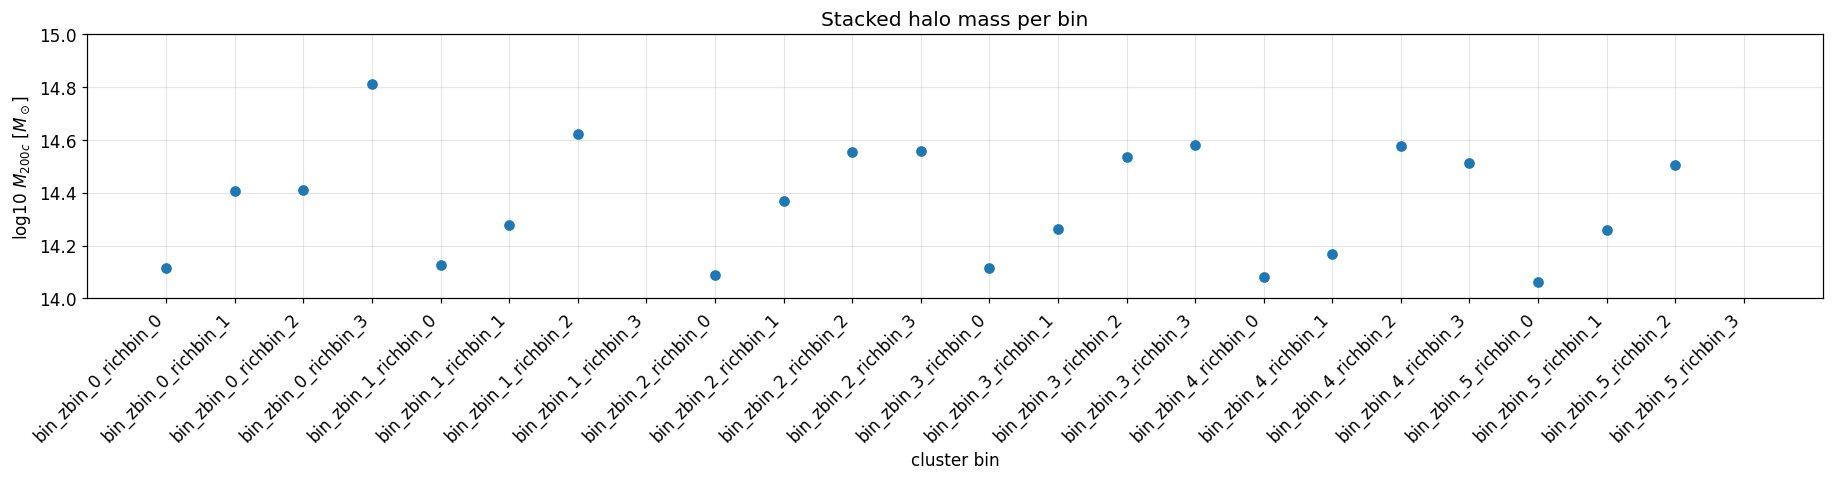

In [10]:
fitted = [r for r in records if r["fitted"]]
fitted.sort(key=lambda r: (
    r["z_mid"] if r["z_mid"] is not None else 0.0,
    r["r_mid"] if r["r_mid"] is not None else 0.0,
    r["bin_key"],
))

labels = [r["bin_key"] for r in fitted]
x = np.arange(len(fitted))
M = np.array([r["m"] for r in fitted])
Merr = np.array([r["m_err"] for r in fitted])

fig, ax = plt.subplots(figsize=(max(6.0, 0.7 * len(fitted)), 4.5))
ax.errorbar(x, np.log10(M), yerr=Merr/(np.log(10)*M), fmt="o", capsize=3, color="C0")
#ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel(r"log10 $M_{200c}\ [M_\odot]$")
ax.set_xlabel("cluster bin")
ax.set_title("Stacked halo mass per bin")
ax.grid(True, which="both", alpha=0.3)
plt.ylim(14, 15)
fig.tight_layout()

## Mass–richness relation, by redshift bin

Only shown if richness edges were parsed above. Each line is one redshift
slice.

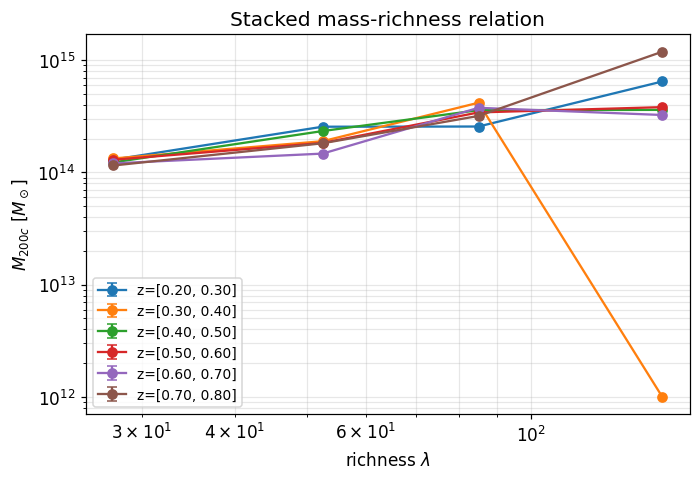

In [5]:
have_rich = len(fitted) > 0 and all(r["r_mid"] is not None for r in fitted)

if have_rich:
    groups = defaultdict(list)
    for r in fitted:
        groups[(r["z_lo"], r["z_hi"])].append(r)

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    for zkey, grp in sorted(groups.items(), key=lambda kv: (kv[0][0] if kv[0][0] is not None else 0)):
        grp = sorted(grp, key=lambda r: r["r_mid"])
        rr = [r["r_mid"] for r in grp]
        mm = [r["m"] for r in grp]
        me = [r["m_err"] for r in grp]
        lbl = (f"z=[{zkey[0]:.2f}, {zkey[1]:.2f}]"
               if zkey[0] is not None else "all z")
        ax.errorbar(rr, mm, yerr=me, fmt="o-", capsize=3, label=lbl)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"richness $\lambda$")
    ax.set_ylabel(r"$M_{200c}\ [M_\odot]$")
    ax.set_title("Stacked mass-richness relation")
    ax.legend(fontsize=9)
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
else:
    print("No richness edges parsed - skipping mass-richness plot.")
    print("Extend parse_edges() to match the keys printed above.")

## Fit diagnostics

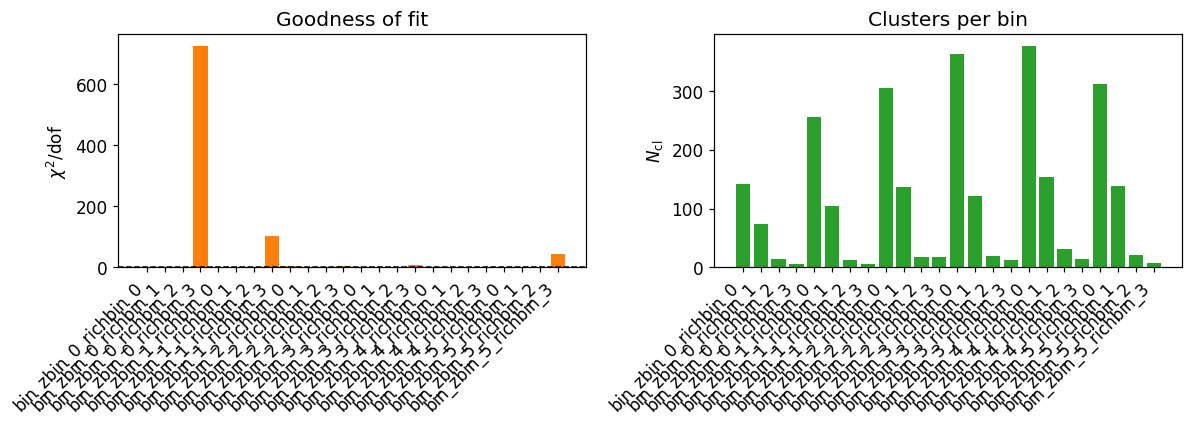

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

chi2 = [r.get("reduced_chi2", np.nan) for r in fitted]
axes[0].bar(x, chi2, color="C1")
axes[0].axhline(1.0, color="k", ls="--", lw=1)
axes[0].set_ylabel(r"$\chi^2/\mathrm{dof}$")
axes[0].set_title("Goodness of fit")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha="right")

axes[1].bar(x, [r.get("n_cl", 0) for r in fitted], color="C2")
axes[1].set_ylabel(r"$N_\mathrm{cl}$")
axes[1].set_title("Clusters per bin")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha="right")

fig.tight_layout()

## Stacked profiles with best-fit NFW overlay

Needs the `CLClusterEnsembleProfiles` pickle (for the data + covariance) and
`clmm` (to recompute the model).

**Important:** the overlay cosmology must match the fiducial cosmology your
pipeline fit with. It defaults below to the CosmoDC2 / Outer Rim cosmology used
in the `mass_fit_cosmodc2` example. For a fixed-mass NFW profile only
`H0`, `Omega_m`, `Omega_b`, `Omega_k` matter (not `sigma8`/`n_s`).

In [7]:
def tan_col(stacked):
    for c in ("tangential_comp", "gt", "tangential_comp_clmm"):
        if c in stacked.colnames:
            return c
    for c in stacked.colnames:
        if "tan" in c:
            return c
    raise KeyError(f"no tangential column in {stacked.colnames}")

try:
    import clmm
    cosmo = clmm.Cosmology(H0=71.0, Omega_dm0=0.2648 - 0.0448,
                           Omega_b0=0.0448, Omega_k0=0.0)
    HAVE_CLMM = True
except Exception as exc:  # pragma: no cover
    HAVE_CLMM = False
    print("clmm not importable, model overlay disabled:", exc)


def predict_profile(radius, logm, z_cl, concentration, is_deltasigma,
                    delta=200, massdef="critical", halo_profile_model="nfw",
                    z_src=1.0):
    common = dict(r_proj=radius, mdelta=10 ** logm, cdelta=concentration,
                  z_cl=z_cl, cosmo=cosmo, delta_mdef=delta,
                  massdef=massdef, halo_profile_model=halo_profile_model)
    if is_deltasigma:
        return clmm.compute_excess_surface_density(**common)
    return clmm.compute_reduced_tangential_shear(
        z_src=z_src, z_src_info="discrete", **common)

In [8]:
profiles = None
if PROFILES_PKL.exists():
    with open(PROFILES_PKL, "rb") as f:
        profiles = pickle.load(f)
else:
    print(f"{PROFILES_PKL} not found - skipping profile overlays.")
    print("Point PROFILES_PKL at your CLClusterEnsembleProfiles output to enable them.")

if profiles is not None and HAVE_CLMM:
    keys = [k for k in profiles
            if profiles[k].get("clmm_cluster_ensemble") is not None
            and masses.get(k, {}).get("ensemble") is not None]

    ncol = 2
    nrow = int(np.ceil(len(keys) / ncol)) if keys else 1
    fig, axes = plt.subplots(nrow, ncol, figsize=(6.2 * ncol, 4.0 * nrow),
                             squeeze=False)
    axflat = axes.ravel()

    for ax, k in zip(axflat, keys):
        ens = profiles[k]["clmm_cluster_ensemble"]
        fit = masses[k]["ensemble"]
        is_ds = masses[k]["is_deltasigma"]

        col = tan_col(ens.stacked_data)
        radius = np.asarray(ens.stacked_data["radius"], float)
        signal = np.asarray(ens.stacked_data[col], float)

        cov = ens.cov.get(fit.get("cov_key")) if fit.get("cov_key") else None
        if cov is not None and np.ndim(cov) == 2:
            err = np.sqrt(np.clip(np.diag(cov), 0.0, None))
        else:
            err = np.full_like(signal, np.nan)

        ax.errorbar(radius, signal, yerr=err, fmt="o", capsize=3,
                    color="k", label="stacked data")

        good = radius > 0
        rr = np.logspace(np.log10(radius[good].min()),
                         np.log10(radius[good].max()), 120)
        model = predict_profile(rr, fit["logm"], masses[k]["z_eff"],
                                fit["concentration"], is_ds)
        ax.plot(rr, model, "-", color="C3", lw=1.5,
                label=(rf'NFW: $M={fit["m"]:.2e}\pm{fit["m_err"]:.1e}$'
                       + "\n" + rf'$\chi^2/$dof$={fit["reduced_chi2"]:.2f}$'))

        ax.set_xscale("log")
        if is_ds:
            ax.set_ylabel(r"$\Delta\Sigma\ [M_\odot/\mathrm{Mpc}^2]$")
            if np.all(signal[np.isfinite(signal)] > 0):
                ax.set_yscale("log")
        else:
            ax.set_ylabel(r"$g_t$")
        ax.set_xlabel(r"$R\ [\mathrm{Mpc}]$")
        ax.set_title(f"bin {k}  (z_eff={masses[k]['z_eff']:.2f}, "
                     f"N={masses[k]['n_cl']})", fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, which="both", alpha=0.3)

    for ax in axflat[len(keys):]:
        ax.set_visible(False)
    fig.tight_layout()

ValueError: 
M=1.30e+14\pmnan
          ^
ParseFatalException: Unknown symbol: \pmnan, found '\'  (at char 10), (line:1, col:11)

Error in callback <function _draw_all_if_interactive at 0x14cf095722a0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
M=1.30e+14\pmnan
          ^
ParseFatalException: Unknown symbol: \pmnan, found '\'  (at char 10), (line:1, col:11)

ValueError: 
M=1.30e+14\pmnan
          ^
ParseFatalException: Unknown symbol: \pmnan, found '\'  (at char 10), (line:1, col:11)

<Figure size 1364x5280 with 24 Axes>

## Individual-cluster masses (if fitted)

Only populated when `fit_individual: true`. Recall these use an approximate
per-cluster error (`sqrt(n_cl)` × stacked error) and are far noisier than the
stacked mass by design — a sanity check, not a measurement.

In [ ]:
bins_with_indiv = [(str(k), entry["individual"])
                   for k, entry in masses.items() if entry.get("individual")]

if not bins_with_indiv:
    print("No individual-cluster fits in this file (fit_individual was False).")
else:
    ncol = 2
    nrow = int(np.ceil(len(bins_with_indiv) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(6.2 * ncol, 3.6 * nrow),
                             squeeze=False)
    axflat = axes.ravel()
    for ax, (k, indiv) in zip(axflat, bins_with_indiv):
        logms = np.array([d.get("logm", np.nan) for d in indiv], float)
        logms = logms[np.isfinite(logms)]
        if logms.size:
            ax.hist(logms, bins=max(5, logms.size // 3), color="C0", alpha=0.7)
        stacked = masses[k]["ensemble"]
        ax.axvline(stacked["logm"], color="C3", lw=2,
                   label=f'stacked logM={stacked["logm"]:.2f}')
        ax.set_xlabel(r"$\log_{10}(M/M_\odot)$")
        ax.set_ylabel("clusters")
        ax.set_title(f"bin {k}  (N={len(indiv)})", fontsize=10)
        ax.legend(fontsize=8)
    for ax in axflat[len(bins_with_indiv):]:
        ax.set_visible(False)
    fig.tight_layout()